K-mer vs foundation model embeddings.
MCC comparison on 57 genomic classification datasets.
Claim: k-mer frequency vectors are as informative as (or better than) pretrained FM embeddings.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_context('paper', font_scale=1.2)

plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 26,   # titoli
    'axes.labelsize': 24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'legend.title_fontsize': 22
})

FIGURES_PDF_DIR = Path('../results/figures_pdf')
FIGURES_PDF_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename):
    path = FIGURES_PDF_DIR / f'{filename}.pdf'
    fig.savefig(path, bbox_inches='tight')
    print(f'Saved figure: {path}')

RECORDS      = '../results/classification/records.csv'
RECORDS_PCA  = '../results/classification/records_pca.csv'
RECORDS_CONCAT = '../results/concat/records_concat_best.csv'

RECORDS_DECOMP = '../results/classification/records_decomposition.csv'
RECORDS_BESTK  = '../results/classification/records_best_k_analysis.csv'
RECORDS_EFF   = '../results/exploratory/efficiency.csv'
RECORDS_REG   = '../results/regression/lra_records.csv'

FM_LABELS = {
    'fm_NTv3_650M_pre_MCC':                        'NTv3-650M',
    'fm_hyenadna-medium-160k-seqlen-hf_MCC':       'HyenaDNA-160k',
    'fm_DNABERT-2-117M_MCC':                       'DNABERT-2',
}

def load_records():
    df = pd.read_csv(RECORDS, index_col=0)
    df.index.name = 'dataset'
    df['group'] = df.index.str.split('/').str[0]
    df['short'] = df.index.str.split('/').str[1]
    return df


def kmer_mcc_cols(df, include_multi=True):
    cols = [c for c in df.columns if c.startswith('kmer_k') and c.endswith('_MCC')]
    if include_multi:
        cols += [c for c in df.columns if c.startswith('kmer_multi') and c.endswith('_MCC')]
    return cols


def fm_mcc_cols(df):
    """Exclude evo2 (all-zero results)."""
    return [c for c in df.columns
            if c.startswith('fm_') and c.endswith('_MCC') and 'evo2' not in c]


def best_kmer(df):
    cols = kmer_mcc_cols(df)
    return df[cols].apply(pd.to_numeric, errors='coerce').max(axis=1).rename('best_kmer_MCC')


def best_fm(df):
    cols = fm_mcc_cols(df)
    return df[cols].apply(pd.to_numeric, errors='coerce').max(axis=1).rename('best_fm_MCC')


def dataset_palette(df):
    groups = sorted(df['group'].dropna().unique())
    cmap = plt.colormaps['tab20']
    return {g: cmap(i) for i, g in enumerate(groups)}


df      = load_records()
df_pca  = pd.read_csv(RECORDS_PCA, index_col=0)
df_pca  = df_pca[~df_pca.index.duplicated(keep='last')]
df_pca['group'] = df_pca.index.str.split('/').str[0]

df_concat = pd.read_csv(RECORDS_CONCAT)
df_decomp = pd.read_csv(RECORDS_DECOMP, index_col=0)
df_bestk  = pd.read_csv(RECORDS_BESTK, index_col=0)
df_eff    = pd.read_csv(RECORDS_EFF)
df_reg    = pd.read_csv(RECORDS_REG)
df_concat = df_concat.set_index('dataset')

palette = dataset_palette(df)

print(f"Records:  {len(df)} datasets, {len(df.columns)} columns")
print(f"PCA:      {len(df_pca)} datasets")
print(f"Concat:   {len(df_concat)} datasets")


Records:  57 datasets, 63 columns
PCA:      58 datasets
Concat:   57 datasets


---
## 1. Per-dataset comparison: FM embeddings vs best k-mer
Each point is a dataset. Above the diagonal: FM wins; below: k-mer wins.  
One subplot per FM model (Evo2 excluded, MCC ≈ 0 across datasets).

Saved figure: ../results/figures_pdf/01-fm-vs-kmer-by-model.pdf


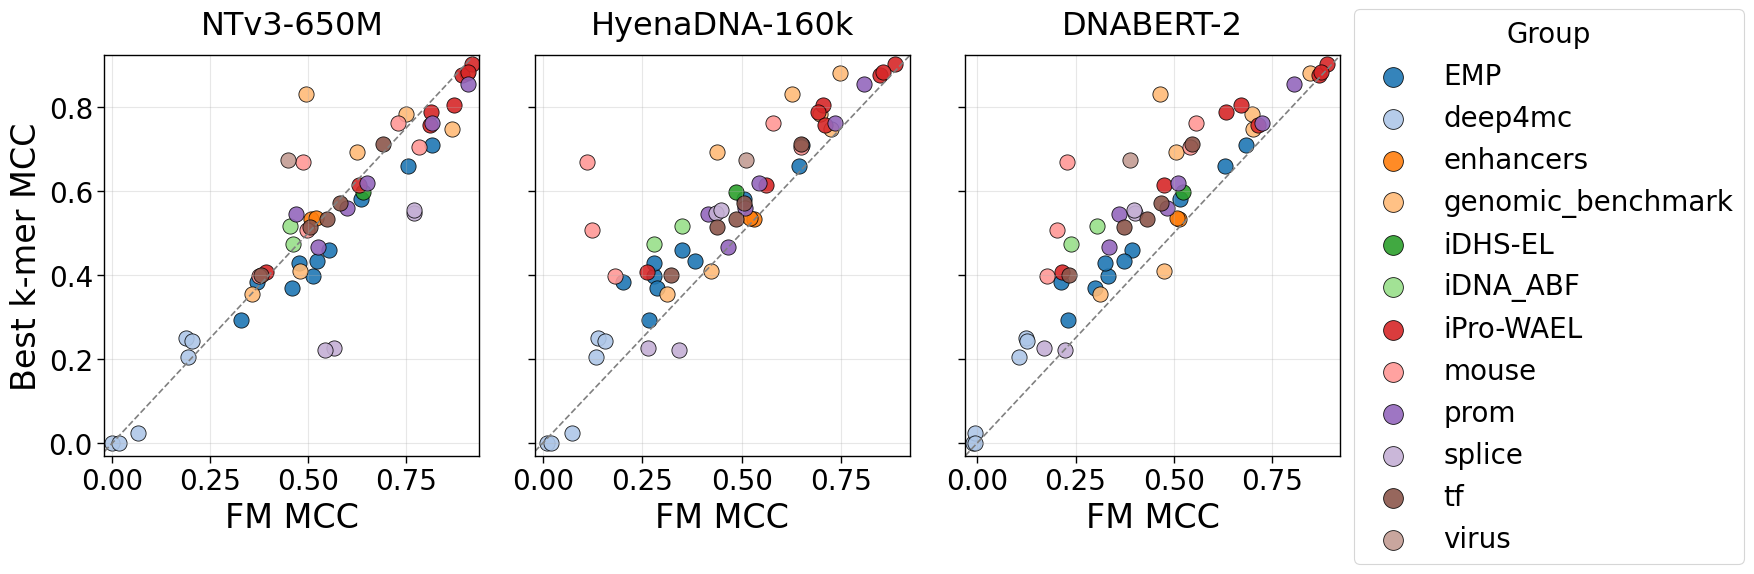

In [2]:
metric = 'MCC'
TIE_EPS = 0.01
best_k = best_kmer(df)
fm_cols = list(FM_LABELS.keys())

# FIX: figsize (15,4.5)->(17,6)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, col in zip(axes, fm_cols):
    x = pd.to_numeric(df[col], errors='coerce')
    y = best_k

    for g, sub in df.groupby('group'):
        ax.scatter(
            x.loc[sub.index], y.loc[sub.index],
            label=g,
            alpha=0.9,       # leggermente più visibili
            s=120,            # prima 55 → più grandi
            color=palette[g],
            edgecolors='black',  # contrasto maggiore
            linewidths=0.6       # contorno più netto
        )

    lo = np.nanmin([x.min(), y.min()]) - 0.02
    hi = np.nanmax([x.max(), y.max()]) + 0.02
    ax.plot([lo, hi], [lo, hi], ls='--', c='gray', lw=1.2)

    #valid = pd.concat([x, y], axis=1).dropna()
    #diff = valid.iloc[:, 0] - valid.iloc[:, 1]
    #fm_wins   = (diff > TIE_EPS).sum()
    #kmer_wins = (diff < -TIE_EPS).sum()
    #ties      = ((diff >= -TIE_EPS) & (diff <= TIE_EPS)).sum()
    #ax.text(0.03, 0.97, f'FM wins: {fm_wins}\nK-mer wins: {kmer_wins}\nTies: {ties}',
    #        transform=ax.transAxes, va='top', fontsize=10,
    #       bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

    ax.set_title(FM_LABELS[col], fontsize=23, pad=15)
    ax.set_xlabel('FM MCC')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

axes[0].set_ylabel('Best k-mer MCC')
axes[-1].legend(
    bbox_to_anchor=(1, 1.15),   # più in alto
    loc='upper left',
    title='Group',
    fontsize=20,
    title_fontsize=20,
    markerscale=1.3,
    framealpha=0.8
)
plt.tight_layout()
save_figure(fig, '01-fm-vs-kmer-by-model')
plt.show()


Saved figure: ../results/figures_pdf/01-fm-vs-kmer-by-model-multipanel.pdf


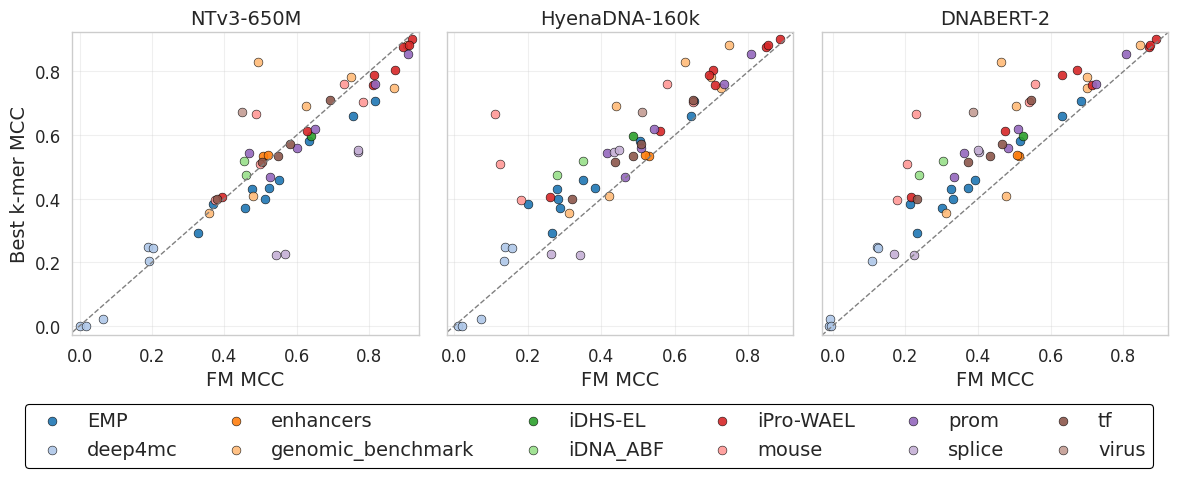

In [35]:
# ── Multi-panel figure (A, B, C) with boxed 2-row legend ───────────────
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

best_k = best_kmer(df)
fm_cols = list(FM_LABELS.keys())

fig, axes = plt.subplots(1, 3, figsize=(12, 4.8), sharey=True)

handles = []
labels = []

for ax, col in zip(axes, fm_cols):
    x = pd.to_numeric(df[col], errors='coerce')
    y = best_k

    for g, sub in df.groupby('group'):
        sc = ax.scatter(
            x.loc[sub.index], y.loc[sub.index],
            alpha=0.9,
            s=40,
            color=palette[g],
            edgecolors='black',
            linewidths=0.4,
            label=g
        )

        if g not in labels:
            handles.append(sc)
            labels.append(g)

    lo = np.nanmin([x.min(), y.min()]) - 0.02
    hi = np.nanmax([x.max(), y.max()]) + 0.02

    ax.plot([lo, hi], [lo, hi], ls='--', c='gray', lw=1.0)

    ax.set_title(FM_LABELS[col], pad=6)
    ax.set_xlabel('FM MCC')
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Best k-mer MCC')

# 🔥 LEGENDA BOXATA SU 2 RIGHE
ncols = int(np.ceil(len(labels) / 2))  # divide su 2 righe

legend = fig.legend(
    handles, labels,
    loc='lower center',
    ncol=ncols,
    frameon=True,
    fontsize=14,
    bbox_to_anchor=(0.5, -0.02)  # leggermente sotto
)

# stile box (più elegante)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(0.8)
legend.get_frame().set_alpha(1)

# spazio extra sotto per la legenda
plt.tight_layout(rect=[0, 0.12, 1, 1])

save_figure(fig, '01-fm-vs-kmer-by-model-multipanel')

plt.show()

**Notes — strongest margins (MCC):**
**K-mer ≫ NTv3 (top 3):**
- `genomic_benchmark/regulatory_region_type` (Δ = -0.336)
- `virus/covid_variants` (Δ = -0.225)
- `mouse/mouse_TFBS_4` (Δ = -0.181)




---
## 2. Summary by biological category
Compact table with per-category means/medians and a plot of the Δ MCC distribution (NTv3 − best k-mer).
Values rounded for readability; prioritize pattern clarity over detail.


In [15]:
import matplotlib as mpl
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("paper")  # IMPORTANTISSIMO

mpl.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
})

,N,Seq len,GC,Best k,MCC k-mer,MCC NTv3,NTv3 wins,R²,Resid > k-mer,Synergy,Δ concat
biocat_label,,,,,,,,,,,
Enhancer/Generic,11,347,0.45,4,0.673,0.519,5,0.43,3,-0.012,-0.021
Histone (Yeast),10,500,0.38,6,0.431,0.518,9,0.49,3,0.062,-0.003
Methylation,8,41,0.49,4,0.224,0.190,2,0.57,3,0.002,-0.025
Promoter,14,450,0.53,4,0.759,0.812,12,0.44,4,0.009,-0.006
Splice,4,500,0.45,4,0.387,0.668,4,0.51,4,0.076,-0.003
TFBS,10,101,0.56,5,0.553,0.526,3,0.49,0,-0.005,-0.007


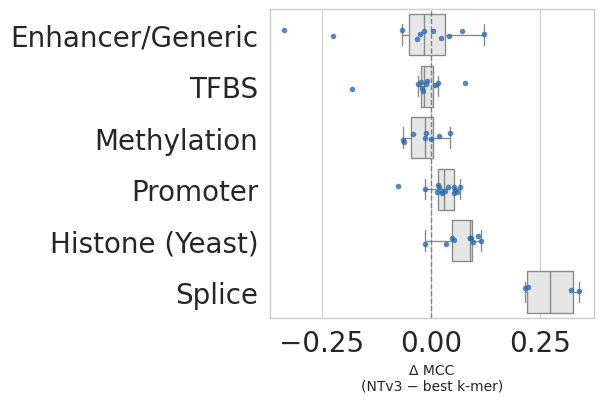

In [14]:
# ── Section 2: category summary ─────────────────────────────────────────
sns.set_style('whitegrid')

CAT_LABELS = {
    'histone': 'Histone (Yeast)',
    'methylation': 'Methylation',
    'promoter': 'Promoter',
    'splice': 'Splice',
    'TFBS': 'TFBS',
    'enhancer/generic': 'Enhancer/Generic',
}

def mode_or_nan(s):
    m = s.mode()
    return m.iloc[0] if len(m) else np.nan

cat = df_bestk[['biocat', 'seq_len_mean', 'gc_content_mean', 'best_k']].copy()
cat['best_kmer_MCC'] = best_kmer(df)
cat['ntv3_MCC'] = pd.to_numeric(df['fm_NTv3_650M_pre_MCC'], errors='coerce')
cat['delta_ntv3_kmer'] = cat['ntv3_MCC'] - cat['best_kmer_MCC']

cat['R2'] = pd.to_numeric(df_decomp['ridge_k6_NTv3_650M_pre_R2'], errors='coerce')
cat['proj_MCC'] = pd.to_numeric(df_decomp['proj_k6_NTv3_650M_pre_MCC'], errors='coerce')
cat['resid_MCC'] = pd.to_numeric(df_decomp['resid_k6_NTv3_650M_pre_MCC'], errors='coerce')
cat['synergy'] = cat['ntv3_MCC'] - np.maximum(cat['proj_MCC'], cat['resid_MCC'])
cat['resid_gt_kmer'] = (cat['resid_MCC'] > cat['best_kmer_MCC']).astype(int)

cat['concat_MCC'] = pd.to_numeric(df_concat['MCC'], errors='coerce')
cat['delta_concat'] = cat['concat_MCC'] - cat[['best_kmer_MCC', 'ntv3_MCC']].max(axis=1)

cat['biocat_label'] = cat['biocat'].map(CAT_LABELS)

summary = (cat
    .groupby('biocat_label')
    .agg(
        N=('best_kmer_MCC', 'count'),
        seq_len=('seq_len_mean', 'mean'),
        GC=('gc_content_mean', 'mean'),
        best_k=('best_k', mode_or_nan),
        MCC_kmer=('best_kmer_MCC', 'median'),
        MCC_NTv3=('ntv3_MCC', 'median'),
        NTv3_wins=('delta_ntv3_kmer', lambda s: (s > 0).sum()),
        R2=('R2', 'mean'),
        resid_gt_kmer=('resid_gt_kmer', 'sum'),
        synergy=('synergy', 'mean'),
        delta_concat=('delta_concat', 'mean'),
    )
)

summary_fmt = summary.copy()
summary_fmt['seq_len'] = summary_fmt['seq_len'].round(0).astype(int)
summary_fmt['GC'] = summary_fmt['GC'].round(2)
summary_fmt['best_k'] = summary_fmt['best_k'].astype('Int64')
summary_fmt['MCC_kmer'] = summary_fmt['MCC_kmer'].round(3)
summary_fmt['MCC_NTv3'] = summary_fmt['MCC_NTv3'].round(3)
summary_fmt['R2'] = summary_fmt['R2'].round(2)
summary_fmt['synergy'] = summary_fmt['synergy'].round(3)
summary_fmt['delta_concat'] = summary_fmt['delta_concat'].round(3)

summary_fmt = summary_fmt.rename(columns={
    'seq_len': 'Seq len', 'GC': 'GC', 'best_k': 'Best k',
    'MCC_kmer': 'MCC k-mer', 'MCC_NTv3': 'MCC NTv3', 'NTv3_wins': 'NTv3 wins',
    'R2': 'R²', 'resid_gt_kmer': 'Resid > k-mer',
    'synergy': 'Synergy', 'delta_concat': 'Δ concat',
})

display(summary_fmt)

order = (cat.groupby('biocat_label')['delta_ntv3_kmer']
         .median().sort_values().index.tolist())

fig, ax = plt.subplots(figsize=(6.5, 4.5))  # più compatto stile paper

sns.boxplot(
    data=cat, y='biocat_label', x='delta_ntv3_kmer', order=order,
    color='#E6E6E6', fliersize=0, linewidth=1.0, ax=ax
)

sns.stripplot(
    data=cat, y='biocat_label', x='delta_ntv3_kmer', order=order,
    size=4, alpha=0.8, color='#2B6CB0', ax=ax
)

ax.axvline(0, ls='--', c='gray', lw=1.0)

ax.set_xlabel('Δ MCC\n(NTv3 − best k-mer)', fontsize=10)
ax.set_ylabel('')

plt.tight_layout()


Saved figure: ../results/figures_pdf/02-category-delta-ntv3-kmer.pdf


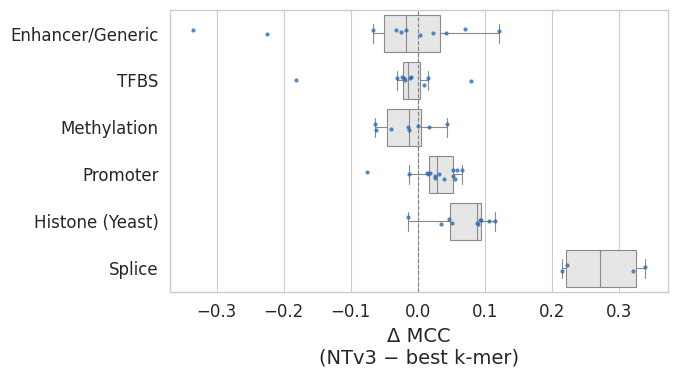

In [22]:
# ── Plot: category delta NTv3 vs best k-mer (paper style) ────────────────
import matplotlib as mpl
import seaborn as sns

# Stile generale
sns.set_style("whitegrid")
sns.set_context("paper")

mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "lines.linewidth": 0.8,
})

# Ordine categorie
order = (cat.groupby('biocat_label')['delta_ntv3_kmer']
         .median().sort_values().index.tolist())

# Figura (dimensione tipica da paper, leggibile)
fig, ax = plt.subplots(figsize=(7, 4))

# Boxplot
sns.boxplot(
    data=cat, y='biocat_label', x='delta_ntv3_kmer', order=order,
    color='#E6E6E6', fliersize=0, linewidth=0.8, ax=ax
)

# Punti
sns.stripplot(
    data=cat, y='biocat_label', x='delta_ntv3_kmer', order=order,
    size=3, alpha=0.8, color='#2B6CB0', ax=ax
)

# Linea verticale a zero
ax.axvline(0, ls='--', c='gray', lw=0.8)

# Label
ax.set_xlabel('Δ MCC\n(NTv3 − best k-mer)')
ax.set_ylabel('')

# Layout compatto
plt.tight_layout()

# Salvataggio
save_figure(fig, '02-category-delta-ntv3-kmer')

plt.show()

---
## 3. Effect of sequence length
Scatter of Δ MCC (NTv3 − best k-mer) vs mean sequence length,
with summary by length bins.


Saved figure: ../results/figures_pdf/03-sequence-length-effect-box-only.pdf


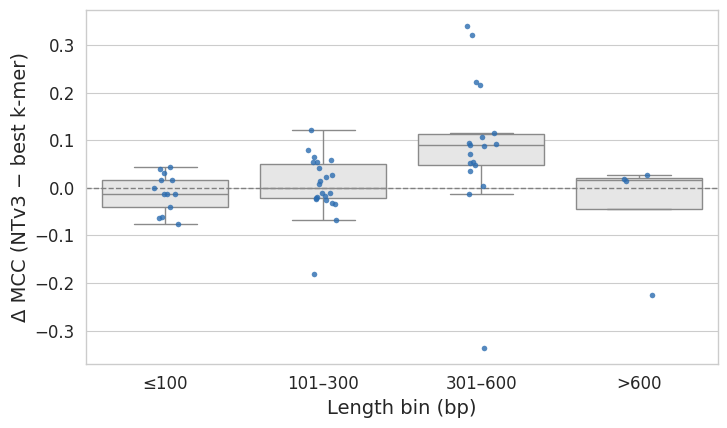

In [24]:
# ── Section 3: sequence length effect (paper style, consistent) ─────────
import matplotlib as mpl
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("paper")

mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "lines.linewidth": 1.0,
})

valid = (cat[['seq_len_mean', 'delta_ntv3_kmer', 'biocat_label']]
         .dropna()
         .rename(columns={'seq_len_mean': 'seq_len'}))

max_len = valid['seq_len'].max()
bins = [0, 100, 300, 600, max_len + 1]
labels = ['≤100', '101–300', '301–600', '>600']
valid['len_bin'] = pd.cut(valid['seq_len'], bins=bins, labels=labels, include_lowest=True)

# Figura coerente con l'altra
fig, ax = plt.subplots(figsize=(7.5, 4.5))

sns.boxplot(
    data=valid,
    x='len_bin',
    y='delta_ntv3_kmer',
    color='#E6E6E6',
    fliersize=0,
    linewidth=1.0,
    ax=ax
)

sns.stripplot(
    data=valid,
    x='len_bin',
    y='delta_ntv3_kmer',
    color='#2B6CB0',
    size=4,          # ↓ molto importante
    alpha=0.8,
    ax=ax
)

ax.axhline(0, ls='--', c='gray', lw=1.0)

ax.set_xlabel('Length bin (bp)')
ax.set_ylabel('Δ MCC (NTv3 − best k-mer)')
#ax.set_title('Δ MCC by length bin', pad=8)

plt.tight_layout()

save_figure(fig, '03-sequence-length-effect-box-only')

plt.show()

---
## 4. Optimal k selection and GC relation
Distribution of `best k` and its relation to GC content.

Saved figure: ../results/figures_pdf/04-best-k-distribution.pdf


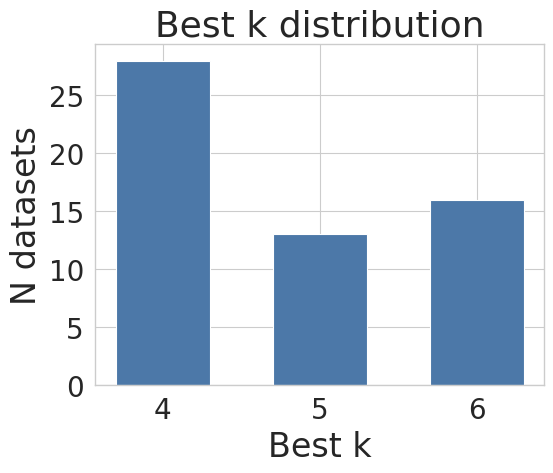

In [5]:
# ── Section 4: best k distribution ───────────────────────────────────
bk = df_bestk.copy()
bk['biocat_label'] = bk['biocat'].map({
    'histone': 'Histone (Yeast)', 'methylation': 'Methylation',
    'promoter': 'Promoter', 'splice': 'Splice',
    'TFBS': 'TFBS', 'enhancer/generic': 'Enhancer/Generic',
})

fig, ax0 = plt.subplots(figsize=(6, 5.2))

counts = bk['best_k'].value_counts().sort_index()
ax0.bar(counts.index.astype(int), counts.values, color='#4C78A8', width=0.6)
ax0.set_xlabel('Best k')
ax0.set_ylabel('N datasets')
ax0.set_title('Best k distribution')
ax0.set_xticks([4, 5, 6])

plt.tight_layout()
save_figure(fig, '04-best-k-distribution')
plt.show()


---
## 5. Embedding decomposition: R², projection, and residual
Compositional redundancy (R²) and comparison of projection/residual vs k-mer.

Saved figure: ../results/figures_pdf/05-decomposition-r2.pdf


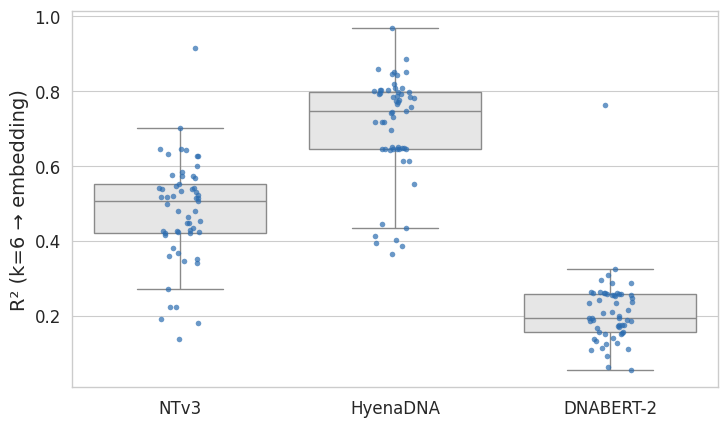

Saved figure: ../results/figures_pdf/05-decomposition-projection-residual.pdf


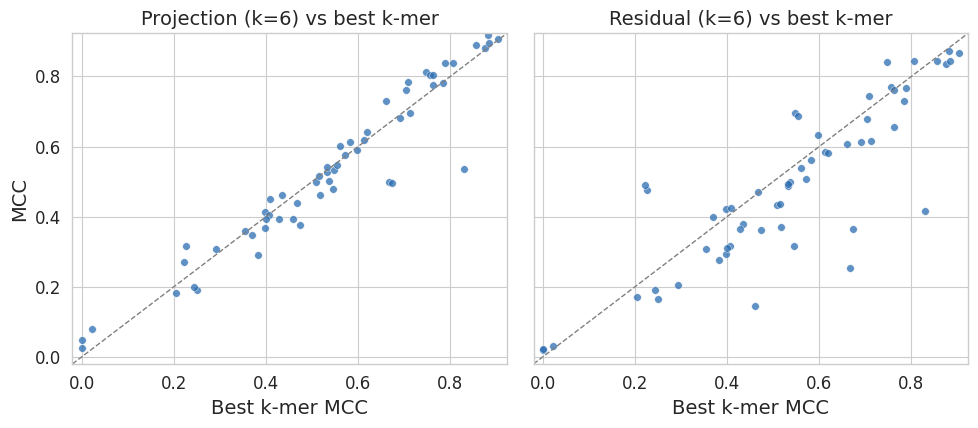

In [28]:
# ── Section 5: decomposition (paper style, consistent) ────────────────
import matplotlib as mpl
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("paper")

mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "lines.linewidth": 1.0,
})

# ── R2 boxplot ────────────────────────────────────────────────────────
r2 = pd.DataFrame({
    'NTv3': pd.to_numeric(df_decomp['ridge_k6_NTv3_650M_pre_R2'], errors='coerce'),
    'HyenaDNA': pd.to_numeric(df_decomp['ridge_k6_hyenadna-medium-160k-seqlen-hf_R2'], errors='coerce'),
    'DNABERT-2': pd.to_numeric(df_decomp['ridge_k6_DNABERT-2-117M_R2'], errors='coerce'),
})
r2_long = r2.melt(var_name='Modello', value_name='R2')

fig, ax = plt.subplots(figsize=(7.5, 4.5))

sns.boxplot(
    data=r2_long, x='Modello', y='R2',
    color='#E6E6E6', fliersize=0, linewidth=1.0, ax=ax
)

sns.stripplot(
    data=r2_long, x='Modello', y='R2',
    color='#2B6CB0', size=4, alpha=0.7, ax=ax
)

ax.set_xlabel('')
ax.set_ylabel('R² (k=6 → embedding)')

plt.tight_layout()
save_figure(fig, '05-decomposition-r2')
plt.show()


# ── Projection vs Residual scatter ─────────────────────────────────────
proj = pd.to_numeric(df_decomp['proj_k6_NTv3_650M_pre_MCC'], errors='coerce')
resid = pd.to_numeric(df_decomp['resid_k6_NTv3_650M_pre_MCC'], errors='coerce')
best_k = best_kmer(df)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)

for ax, y, title in [
    (axes[0], proj, 'Projection (k=6) vs best k-mer'),
    (axes[1], resid, 'Residual (k=6) vs best k-mer')
]:
    ax.scatter(
        best_k, y,
        s=30,                 # ↓ ridotto (prima 55)
        alpha=0.75,
        color='#2B6CB0',
        edgecolors='white',
        linewidth=0.4
    )

    lo = np.nanmin([best_k.min(), y.min()]) - 0.02
    hi = np.nanmax([best_k.max(), y.max()]) + 0.02

    ax.plot([lo, hi], [lo, hi], ls='--', c='gray', lw=1.0)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    ax.set_title(title, pad=6)
    ax.set_xlabel('Best k-mer MCC')

axes[0].set_ylabel('MCC')

plt.tight_layout()
save_figure(fig, '05-decomposition-projection-residual')
plt.show()

---
## 6. Synergy between components
Distribution of synergy (full − max(proj, resid)) by category.

Saved figure: ../results/figures_pdf/06-synergy-by-category.pdf


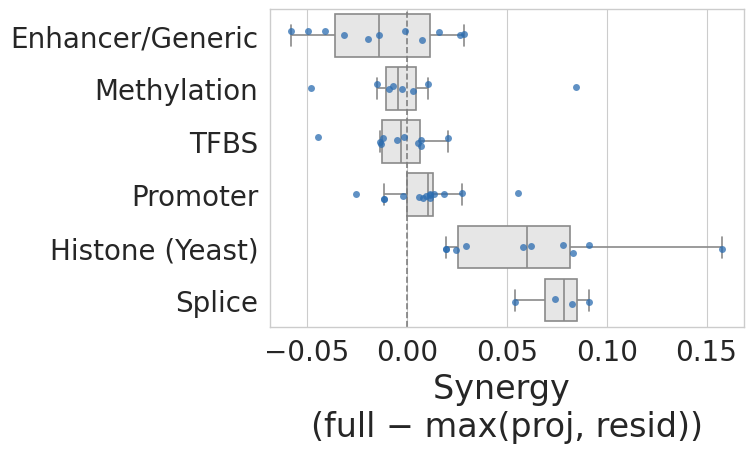

In [7]:
# ── Section 6: synergy ──────────────────────────────────────────────
sy = cat[['biocat_label', 'synergy']].dropna()
order = sy.groupby('biocat_label')['synergy'].median().sort_values().index.tolist()

# FIX: figsize (7.2,4.2)->(8,5)
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=sy, y='biocat_label', x='synergy', order=order,
            color='#E6E6E6', fliersize=0, linewidth=1.2, ax=ax)
sns.stripplot(data=sy, y='biocat_label', x='synergy', order=order,
              size=5, alpha=0.75, color='#2B6CB0', ax=ax)
ax.axvline(0, ls='--', c='gray', lw=1.2)
ax.set_xlabel('Synergy \n(full − max(proj, resid))')
ax.set_ylabel('')
plt.tight_layout()
save_figure(fig, '06-synergy-by-category')
plt.show()


---
## 7. Component comparison by model
MCC distributions for full embedding, projection, and residual.

/tmp/ipykernel_2672436/673347140.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Full', 'Proj.', 'Resid.'], rotation=30, ha='right', fontsize=11)
/tmp/ipykernel_2672436/673347140.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Full', 'Proj.', 'Resid.'], rotation=30, ha='right', fontsize=11)
/tmp/ipykernel_2672436/673347140.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Full', 'Proj.', 'Resid.'], rotation=30, ha='right', fontsize=11)


Saved figure: ../results/figures_pdf/07_component_comparison_by_model.pdf


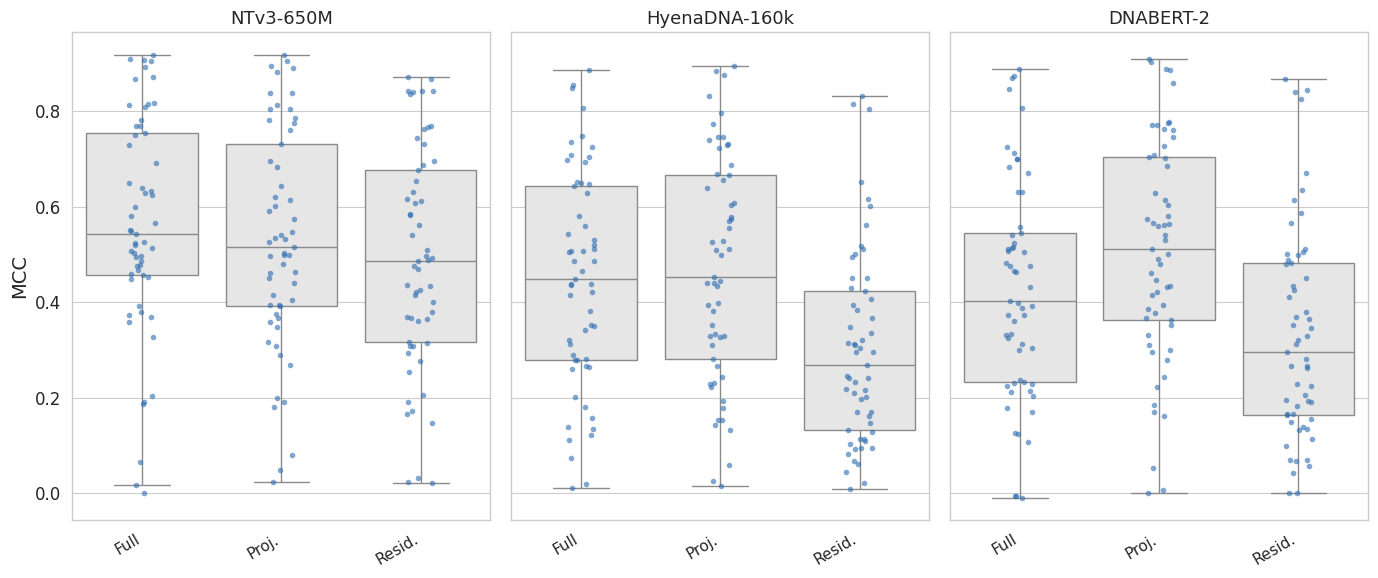

In [29]:
# ── Section 7: model comparison ────────────────────────────────────
def to_num(s):
    return pd.to_numeric(s, errors='coerce')

comp = []
comp.append(pd.DataFrame({'Modello':'NTv3-650M', 'Componente':'Full', 'MCC': to_num(df['fm_NTv3_650M_pre_MCC'])}))
comp.append(pd.DataFrame({'Modello':'NTv3-650M', 'Componente':'Projection', 'MCC': to_num(df_decomp['proj_k6_NTv3_650M_pre_MCC'])}))
comp.append(pd.DataFrame({'Modello':'NTv3-650M', 'Componente':'Residual', 'MCC': to_num(df_decomp['resid_k6_NTv3_650M_pre_MCC'])}))
comp.append(pd.DataFrame({'Modello':'HyenaDNA-160k', 'Componente':'Full', 'MCC': to_num(df['fm_hyenadna-medium-160k-seqlen-hf_MCC'])}))
comp.append(pd.DataFrame({'Modello':'HyenaDNA-160k', 'Componente':'Projection', 'MCC': to_num(df_decomp['proj_k6_hyenadna-medium-160k-seqlen-hf_MCC'])}))
comp.append(pd.DataFrame({'Modello':'HyenaDNA-160k', 'Componente':'Residual', 'MCC': to_num(df_decomp['resid_k6_hyenadna-medium-160k-seqlen-hf_MCC'])}))
comp.append(pd.DataFrame({'Modello':'DNABERT-2', 'Componente':'Full', 'MCC': to_num(df['fm_DNABERT-2-117M_MCC'])}))
comp.append(pd.DataFrame({'Modello':'DNABERT-2', 'Componente':'Projection', 'MCC': to_num(df_decomp['proj_k6_DNABERT-2-117M_MCC'])}))
comp.append(pd.DataFrame({'Modello':'DNABERT-2', 'Componente':'Residual', 'MCC': to_num(df_decomp['resid_k6_DNABERT-2-117M_MCC'])}))

comp = pd.concat(comp, ignore_index=True).dropna()

# FIX: figsize (12.6,4.2)->(14,6); rotation 15->30; labels abbreviated
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=True)
for ax, model in zip(axes, ['NTv3-650M', 'HyenaDNA-160k', 'DNABERT-2']):
    sub = comp[comp['Modello'] == model]
    sns.boxplot(data=sub, x='Componente', y='MCC', color='#E6E6E6', fliersize=0, ax=ax,
                order=['Full', 'Projection', 'Residual'])
    sns.stripplot(data=sub, x='Componente', y='MCC', color='#2B6CB0', size=4, alpha=0.6, ax=ax,
                  order=['Full', 'Projection', 'Residual'])
    ax.set_title(model, fontsize=13)
    ax.set_xlabel('')
    ax.set_xticklabels(['Full', 'Proj.', 'Resid.'], rotation=30, ha='right', fontsize=11)
axes[0].set_ylabel('MCC')
plt.tight_layout()
save_figure(fig, '07_component_comparison_by_model')
plt.show()


---
## 8. FM + k-mer concatenation
Distribution of Δ MCC for concatenation vs the best single method.

Saved figure: ../results/figures_pdf/08_concatenation_delta.pdf


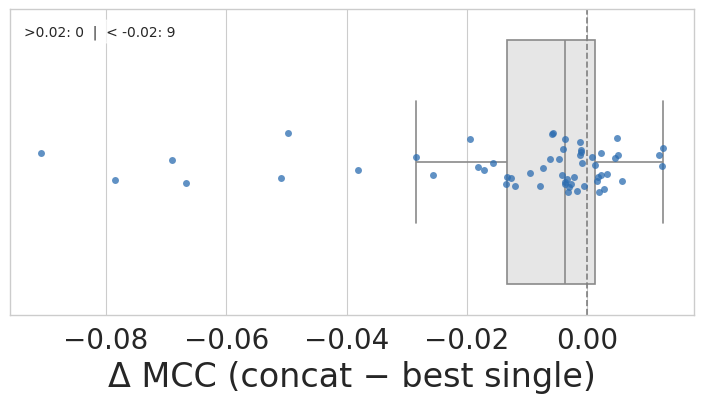

In [9]:
# ── Section 8: concatenation ───────────────────────────────────────
delta_c = cat['delta_concat'].dropna()
n_pos = (delta_c > 0.02).sum()
n_neg = (delta_c < -0.02).sum()

# FIX: figsize (6.5,4.0)->(7.5,4.5)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.boxplot(x=delta_c, color='#E6E6E6', fliersize=0, linewidth=1.2, ax=ax)
sns.stripplot(x=delta_c, color='#2B6CB0', size=5, alpha=0.75, ax=ax)
ax.axvline(0, ls='--', c='gray', lw=1.2)
ax.set_xlabel('Δ MCC (concat − best single)')
ax.set_yticks([])
ax.text(0.02, 0.95, f">0.02: {n_pos}  |  < -0.02: {n_neg}",
        transform=ax.transAxes, va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
plt.tight_layout()
save_figure(fig, '08_concatenation_delta')
plt.show()


---
## 9. PCA effect
Δ MCC (PCA − native) for each representation.

Saved figure: ../results/figures_pdf/09_pca_effect.pdf


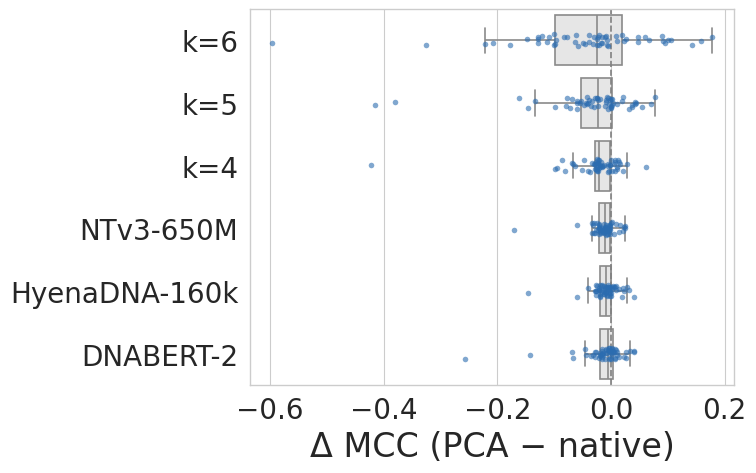

In [10]:
# ── Section 9: PCA effect ─────────────────────────────────────────-
pca_cols = {
    'NTv3-650M': ('pca_fm_NTv3_650M_pre_MCC', 'fm_NTv3_650M_pre_MCC'),
    'HyenaDNA-160k': ('pca_fm_hyenadna-medium-160k-seqlen-hf_MCC', 'fm_hyenadna-medium-160k-seqlen-hf_MCC'),
    'DNABERT-2': ('pca_fm_DNABERT-2-117M_MCC', 'fm_DNABERT-2-117M_MCC'),
    'k=4': ('pca_kmer_k4_MCC', 'kmer_k4_MCC'),
    'k=5': ('pca_kmer_k5_MCC', 'kmer_k5_MCC'),
    'k=6': ('pca_kmer_k6_MCC', 'kmer_k6_MCC'),
}

delta_list = []
for name, (pca_col, raw_col) in pca_cols.items():
    if pca_col in df_pca.columns and raw_col in df.columns:
        d = pd.to_numeric(df_pca[pca_col], errors='coerce') - pd.to_numeric(df[raw_col], errors='coerce')
        delta_list.append(pd.DataFrame({'Method': name, 'Δ MCC': d}))

delta_df = pd.concat(delta_list, ignore_index=True).dropna()
order = (delta_df.groupby('Method')['Δ MCC'].median().sort_values().index.tolist())

# FIX: figsize (7.2,4.2)->(8,5.2)
fig, ax = plt.subplots(figsize=(8, 5.2))
sns.boxplot(data=delta_df, y='Method', x='Δ MCC', order=order, color='#E6E6E6',
            fliersize=0, linewidth=1.2, ax=ax)
sns.stripplot(data=delta_df, y='Method', x='Δ MCC', order=order, color='#2B6CB0',
              size=4, alpha=0.6, ax=ax)
ax.axvline(0, ls='--', c='gray', lw=1.2)
ax.set_xlabel('Δ MCC (PCA − native)')
ax.set_ylabel('')
plt.tight_layout()
save_figure(fig, '09_pca_effect')
plt.show()


---
## 10. Compute cost (GFLOPS)
Per-sequence cost scaling with sequence length.

Saved figure: ../results/figures_pdf/10_efficiency_gflops_per_seq.pdf


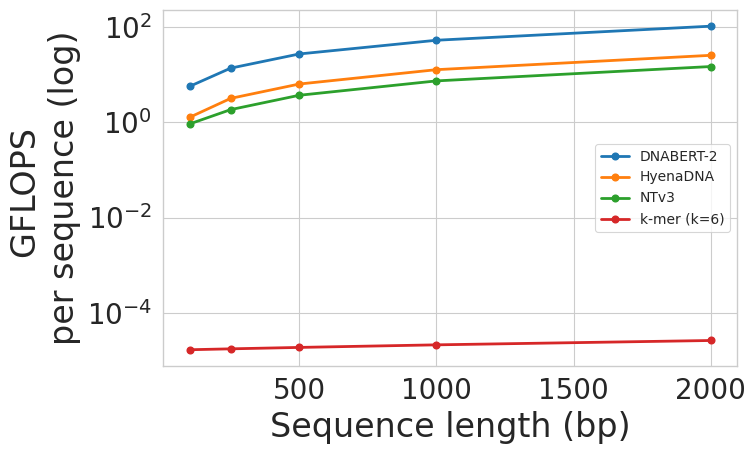

In [11]:
# ── Section 10: efficiency ─────────────────────────────────────────
eff = df_eff.copy()
eff['seq_len'] = pd.to_numeric(eff['seq_len'], errors='coerce')
eff['GFLOPS_per_seq'] = pd.to_numeric(eff['GFLOPS_per_seq'], errors='coerce')

method_map = {
    'fm_NTv3_650M_pre': 'NTv3',
    'fm_hyenadna-medium-160k-seqlen-hf': 'HyenaDNA',
    'fm_DNABERT-2-117M': 'DNABERT-2',
    'kmer_k6': 'k-mer (k=6)',
}
eff['Method'] = eff['method'].map(method_map)
eff = eff.dropna(subset=['Method'])

# FIX: figsize (7.0,4.2)->(8,5)
fig, ax = plt.subplots(figsize=(8, 5))
for m, sub in eff.groupby('Method'):
    sub = sub.sort_values('seq_len')
    ax.plot(sub['seq_len'], sub['GFLOPS_per_seq'], marker='o', lw=2, label=m)

ax.set_yscale('log')
ax.set_xlabel('Sequence length (bp)')
ax.set_ylabel('GFLOPS \nper sequence (log)')
ax.legend(fontsize=10)
plt.tight_layout()
save_figure(fig, '10_efficiency_gflops_per_seq')
plt.show()


---
## 11. Cross-experiment correlations
Spearman correlation heatmap for key variables.

Saved figure: ../results/figures_pdf/11_cross_experiment_correlations.pdf


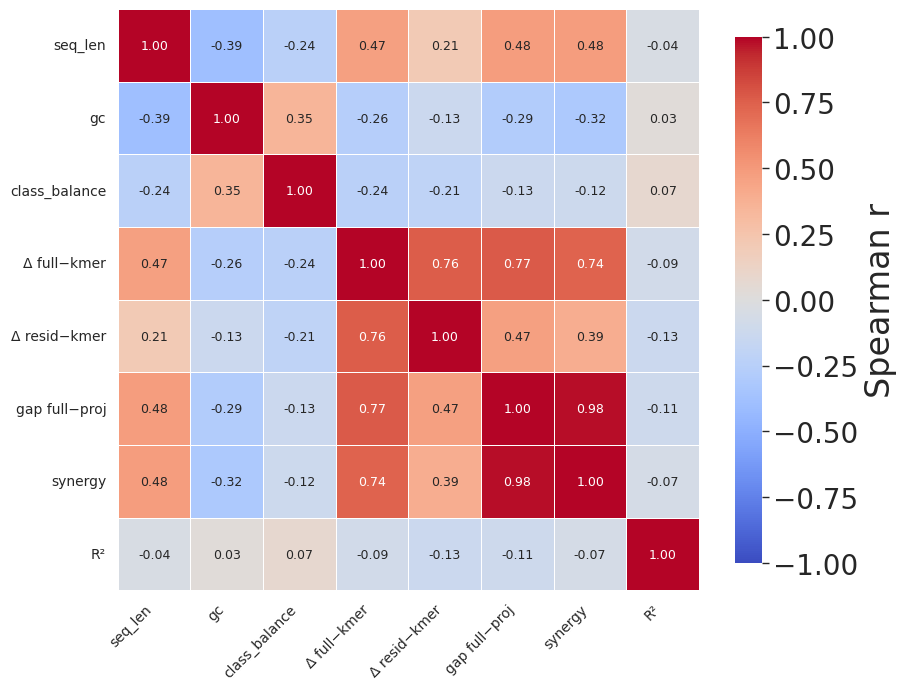

In [12]:
# ── Section 11: correlations ───────────────────────────────────────
corr = pd.DataFrame(index=df.index)
corr['seq_len'] = pd.to_numeric(df['seq_len_mean'], errors='coerce')
corr['gc'] = pd.to_numeric(df['gc_content_mean'], errors='coerce')
corr['class_balance'] = pd.to_numeric(df['class_balance'], errors='coerce')
corr['delta_full_kmer'] = pd.to_numeric(df['fm_NTv3_650M_pre_MCC'], errors='coerce') - best_kmer(df)
corr['delta_resid_kmer'] = pd.to_numeric(df_decomp['resid_k6_NTv3_650M_pre_MCC'], errors='coerce') - best_kmer(df)
corr['gap_full_proj'] = pd.to_numeric(df['fm_NTv3_650M_pre_MCC'], errors='coerce') - pd.to_numeric(df_decomp['proj_k6_NTv3_650M_pre_MCC'], errors='coerce')
corr['synergy'] = cat['synergy']
corr['R2'] = pd.to_numeric(df_decomp['ridge_k6_NTv3_650M_pre_R2'], errors='coerce')

corr = corr.dropna()

corr = corr.rename(columns={
    'seq_len': 'seq_len', 'gc': 'gc', 'class_balance': 'class_balance',
    'delta_full_kmer': 'Δ full−kmer', 'delta_resid_kmer': 'Δ resid−kmer',
    'gap_full_proj': 'gap full−proj', 'synergy': 'synergy', 'R2': 'R²',
})

rho = corr.corr(method='spearman')

# FIX: figsize (7.0,5.6)->(9.5,8); annot=True; rotated x-labels
fig, ax = plt.subplots(figsize=(9.5, 8))
sns.heatmap(rho, cmap='coolwarm', vmin=-1, vmax=1, center=0,
            square=True,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            cbar_kws={'label': 'Spearman r', 'shrink': 0.8},
            linewidths=0.5,
            ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()
save_figure(fig, '11_cross_experiment_correlations')
plt.show()


---
## 12. Regression tasks (LRA)
Summary of performance on available regression datasets.

,k-mer (best k),NTv3-650M,HyenaDNA-1M,DNABERT-2
dataset,,,,
bulk_rna_expression,0.412,0.464,0.386,0.193
cage_prediction,0.573,0.518,0.567,0.400


Saved figure: ../results/figures_pdf/12_regression_r2_summary.pdf


/tmp/ipykernel_2672436/1661130347.py:34: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=reg_long, y='dataset', x='R2', hue='Method', orient='h', ci=None, ax=ax)


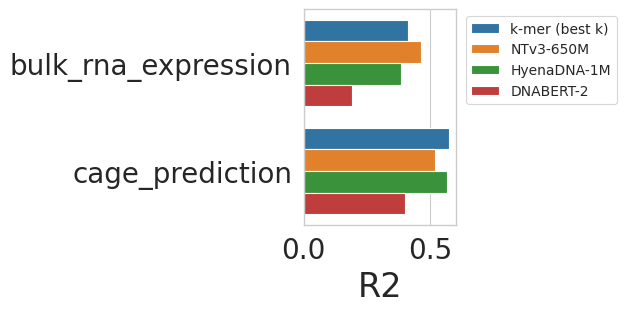

In [13]:
# ── Section 12: regression tasks ───────────────────────────────────
reg = df_reg.copy()
reg = reg.set_index('dataset')

# keep only datasets with regression metrics
r2_cols = [c for c in reg.columns if c.endswith('_R2')]
reg = reg[reg[r2_cols].notna().any(axis=1)]

# best k-mer (R2)
reg_k = reg[[c for c in reg.columns if c.startswith('kmer_k') and c.endswith('_R2')]]
reg['best_kmer_R2'] = reg_k.apply(pd.to_numeric, errors='coerce').max(axis=1)

# compact table (R2)
reg_table = reg[[
    'best_kmer_R2',
    'fm_NTv3_650M_pre_R2',
    'fm_hyenadna-large-1m-seqlen-hf_R2',
    'fm_DNABERT-2-117M_R2'
]].copy()
reg_table = reg_table.rename(columns={
    'best_kmer_R2': 'k-mer (best k)',
    'fm_NTv3_650M_pre_R2': 'NTv3-650M',
    'fm_hyenadna-large-1m-seqlen-hf_R2': 'HyenaDNA-1M',
    'fm_DNABERT-2-117M_R2': 'DNABERT-2',
})
reg_table = reg_table.round(3)

display(reg_table)

# plot: R2 by dataset and method
reg_long = reg_table.reset_index().melt(id_vars='dataset', var_name='Method', value_name='R2')

fig, ax = plt.subplots(figsize=(6.8, 3.6))
sns.barplot(data=reg_long, y='dataset', x='R2', hue='Method', orient='h', ci=None, ax=ax)
ax.set_xlabel('R2')
ax.set_ylabel('')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()
save_figure(fig, '12_regression_r2_summary')
plt.show()